# 02 — AI Model Size Trends

This notebook shows how the framework projects AI model sizes over the 15-year
simulation horizon, using historical data from the Epoch AI dataset.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from dc_tco.config import load_config
from dc_tco.models import (
    load_notable_models,
    compute_yearly_stats,
    project_model_sizes,
    get_model_at_quarter,
)

In [2]:
cfg = load_config('../configs/default.yaml')

## Historical Model Sizes (Epoch AI)

               p50           p99          mean
year                                          
2015  1.630000e+07  2.439894e+08  3.925679e+07
2016  3.200000e+07  2.408000e+08  4.210074e+07
2017  3.400000e+07  6.493380e+09  3.603765e+08
2018  8.650000e+07  7.180000e+09  6.437041e+08
2019  2.280000e+08  6.850000e+10  2.967894e+09
2020  2.435000e+08  1.039000e+11  5.461316e+09
2021  1.671500e+09  1.307590e+12  8.274112e+10
2022  4.750000e+09  5.403500e+11  6.609539e+10
2023  1.100000e+10  6.561400e+11  5.450078e+10
2024  7.000000e+10  5.976800e+11  1.118076e+11
2025  3.200000e+10  1.893680e+12  3.230478e+11


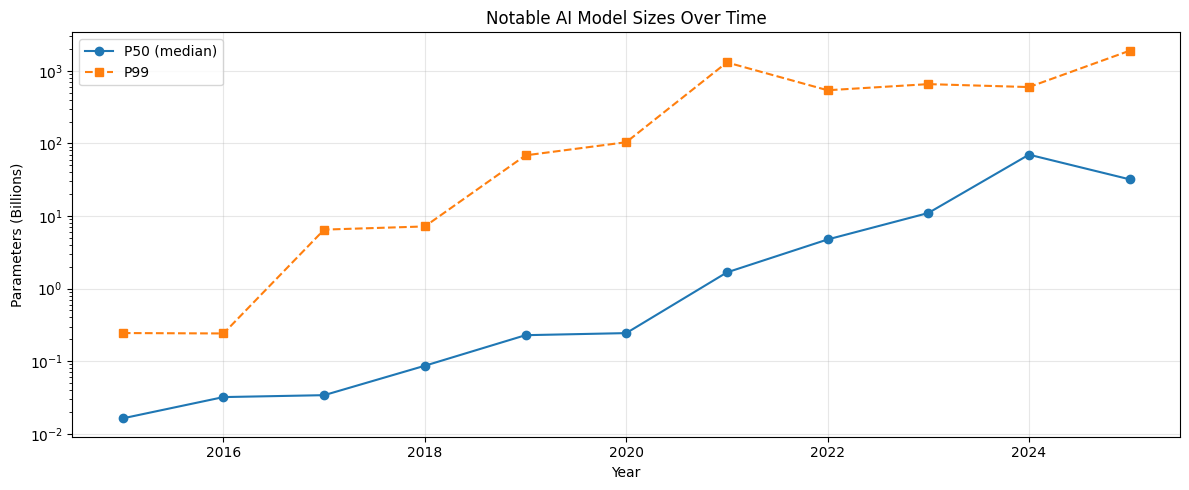

In [3]:
df = load_notable_models('../data/notable_ai_models.csv')
yearly = compute_yearly_stats(df)
print(yearly)
fig, ax = plt.subplots(figsize=(12, 5))
years = yearly.index.tolist()
p50 = (yearly['p50'] / 1e9).tolist()
p99 = (yearly['p99'] / 1e9).tolist()

ax.plot(years, p50, 'o-', label='P50 (median)', color='tab:blue')
ax.plot(years, p99, 's--', label='P99', color='tab:orange')
ax.set_yscale('log')
ax.set_xlabel('Year')
ax.set_ylabel('Parameters (Billions)')
ax.set_title('Notable AI Model Sizes Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Projected Model Sizes Over Simulation Horizon

[0.0163, 0.0163, 0.0163, 0.0163, 0.032, 0.032, 0.032, 0.032, 0.034, 0.034, 0.034, 0.034, 0.0865, 0.0865, 0.0865, 0.0865, 0.228, 0.228, 0.228, 0.228, 0.2435, 0.2435, 0.2435, 0.2435, 1.6715, 1.6715, 1.6715, 1.6715, 4.75, 4.75, 4.75, 4.75, 11.0, 11.0, 11.0, 11.0, 70.0, 70.0, 70.0, 70.0, 32.0, 32.0, 32.0, 32.0, 37.28520000000195, 37.28520000000195, 37.28520000000195, 37.28520000000195, 41.680281818183595, 41.680281818183595, 41.680281818183595, 41.680281818183595, 46.07536363636523, 46.07536363636523, 46.07536363636523, 46.07536363636523, 50.470445454546876, 50.470445454546876, 50.470445454546876, 50.470445454546876]


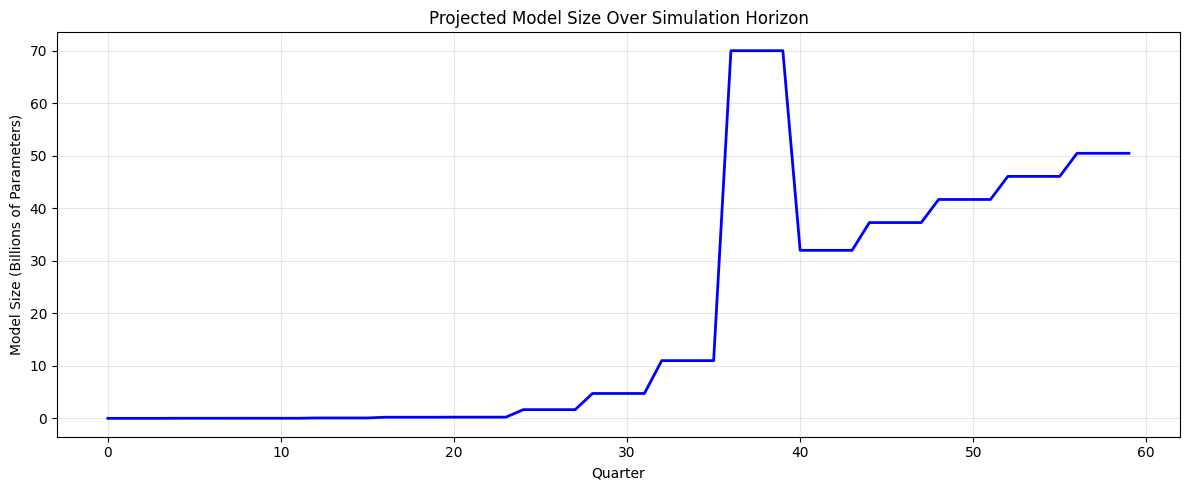

In [4]:
model_sizes = project_model_sizes(cfg)
quarters = list(range(cfg.simulation.num_quarters))
sizes_B = [s / 1e9 for s in model_sizes]
print(sizes_B)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(quarters, sizes_B, 'b-', linewidth=2)
ax.set_xlabel('Quarter')
ax.set_ylabel('Model Size (Billions of Parameters)')
ax.set_title('Projected Model Size Over Simulation Horizon')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Model Migration & Distillation

The framework models distillation (a smaller model at 10% of the full model's size)
and migration between model generations.

In [5]:
base_year = cfg.simulation.base_year
num_years = cfg.simulation.total_years
qpy = cfg.simulation.quarters_per_year

for year in range(base_year, base_year + num_years):
    q = (year - base_year) * qpy
    info = get_model_at_quarter(q, model_sizes, cfg)
    print(f'{year}: primary={info.primary_model_size/1e6:.1f}M  '
          f'distilled={info.distilled_model_size/1e6:.1f}M  '
          f'migration_frac={info.migration_fraction:.2f}')

2015: primary=16.3M  distilled=1.6M  migration_frac=0.10
2016: primary=32.0M  distilled=1.6M  migration_frac=0.10
2017: primary=34.0M  distilled=3.2M  migration_frac=0.10
2018: primary=86.5M  distilled=3.4M  migration_frac=0.10
2019: primary=228.0M  distilled=8.7M  migration_frac=0.10
2020: primary=243.5M  distilled=22.8M  migration_frac=0.10
2021: primary=1671.5M  distilled=24.4M  migration_frac=0.10
2022: primary=4750.0M  distilled=167.2M  migration_frac=0.10
2023: primary=11000.0M  distilled=475.0M  migration_frac=0.10
2024: primary=70000.0M  distilled=1100.0M  migration_frac=0.10
2025: primary=32000.0M  distilled=7000.0M  migration_frac=0.10
2026: primary=37285.2M  distilled=3200.0M  migration_frac=0.10
2027: primary=41680.3M  distilled=3728.5M  migration_frac=0.10
2028: primary=46075.4M  distilled=4168.0M  migration_frac=0.10
2029: primary=50470.4M  distilled=4607.5M  migration_frac=0.10
